# **Day 3 — Computer Vision Preprocessing with OpenCV**

## **Image Preprocessing**

***"Garbage in, garbage out."***

This old machine learning adage conveys that, **unless input data is of high quality, model accuracy** - even with the best computer vision architectures - **will suffer**. Collecting high quality data for the task is of high importance, but preprocessing allows the best possible results to be obtained.

Image preprocessing is the steps taken **to format images before they are used by model training and inference**. This includes, but is not limited to, resizing, color correction, normalization, and edge detection.
**Reducing image sizes for instance, will dramatically improve model training time without significantly reducing performance**.

Preprocessing is essential for cleaning images before used in computer vison models. Fully connected layers in CNNs require all images to be of the same array size, if not, You are likely to encounter an error.

## **OpenCV**

OpenCV is an open-source library used for a wide range of computer vision tasks, including image processing, object detection, and feature extraction. It provides interfaces for multiple programming languages such as Python, C++, and Java.

Unlike humans, computers don't *"see"* images, they interpret them as numeric matrices. Each image is made of pixels and each pixel holds values for color and brightness. Images are stored as NumPy arrays. Preprocessing algortihms manipulate these arrays to apply transformations like edge detection, blurring or object detection.

OpenCV **processes visual data through a sequence of operations that transform images to meaningful information**; Input aquisition, Data preprocessing, feature processing, result analysis and output generation.

## **Data Augmentation**

Applying augmentation on a small dataset expands the dataset and forces the model to generalize and recognize patterns rather than memorize, which forms an overfitting prevention mechanism in image classification projects.

## **Transfer Learning**

As mentioned in week 7, transfer learning is a technique were a model trained on one task is reused for a related task. This approach is *used when having a limited amount of data*. In order to achieve good transfer learning results, the preprocessing must match that of the initial base model.

## **Imports**

In [1]:
import pandas as pd
import os
import cv2
import numpy as np
import random
from google.colab import drive
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

## **Uploading the Bag Class dataset**

In [2]:
drive.mount('/content/drive')

import zipfile
with zipfile.ZipFile("/content/drive/MyDrive/bag_classes.zip", "r") as zip_ref:
    zip_ref.extractall("data/")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
for root, dirs, files in os.walk("data/"):
    print(root, "->", dirs, files[:5])  # just show first 5 files per folder

data/ -> ['__MACOSX', 'Bag Classes'] []
data/__MACOSX -> ['Bag Classes'] ['._Bag Classes']
data/__MACOSX/Bag Classes -> ['Plastic Bag Images', 'Garbage Bag Images', 'Paper Bag Images'] ['._Paper Bag Images', '._Garbage Bag Images', '._Plastic Bag Images']
data/__MACOSX/Bag Classes/Plastic Bag Images -> [] ['._00001570.jpg', '._00004842.jpg', '._00003170.jpg', '._00004632.jpg', '._00003279.jpg']
data/__MACOSX/Bag Classes/Garbage Bag Images -> [] ['._00001570.jpg', '._00004842.jpg', '._00003170.jpg', '._00004632.jpg', '._00003279.jpg']
data/__MACOSX/Bag Classes/Paper Bag Images -> [] ['._00001570.jpg', '._00004842.jpg', '._00003170.jpg', '._00004632.jpg', '._00003279.jpg']
data/Bag Classes -> ['Plastic Bag Images', 'Garbage Bag Images', 'Paper Bag Images'] []
data/Bag Classes/Plastic Bag Images -> [] ['00001424.jpg', '00004491.jpg', '00001864.jpg', '00000724.jpg', '00000367.jpg']
data/Bag Classes/Garbage Bag Images -> [] ['00001424.jpg', '00004491.jpg', '00001864.jpg', '00000724.jpg', '0

In [4]:
base = "data/Bag Classes"
records = []

for folder_name in os.listdir(base):
  folder_path = os.path.join(base, folder_name)
  if os.path.isdir(folder_path):
    for filename in os.listdir(folder_path):
      if filename.startswith("._"):
        continue
      records.append({
        "filepath": os.path.join(folder_path, filename),
        "label" : folder_name
      })

df = pd.DataFrame(records)
print(df.shape)
print(df.head())
print(df["label"].value_counts())

(15000, 2)
                                           filepath               label
0  data/Bag Classes/Plastic Bag Images/00001424.jpg  Plastic Bag Images
1  data/Bag Classes/Plastic Bag Images/00004491.jpg  Plastic Bag Images
2  data/Bag Classes/Plastic Bag Images/00001864.jpg  Plastic Bag Images
3  data/Bag Classes/Plastic Bag Images/00000724.jpg  Plastic Bag Images
4  data/Bag Classes/Plastic Bag Images/00000367.jpg  Plastic Bag Images
label
Plastic Bag Images    5000
Garbage Bag Images    5000
Paper Bag Images      5000
Name: count, dtype: int64


After checking that the data is in proper file structure, proceed to clean it with OpenCV library

### **Check Classes for Mislabled Images**

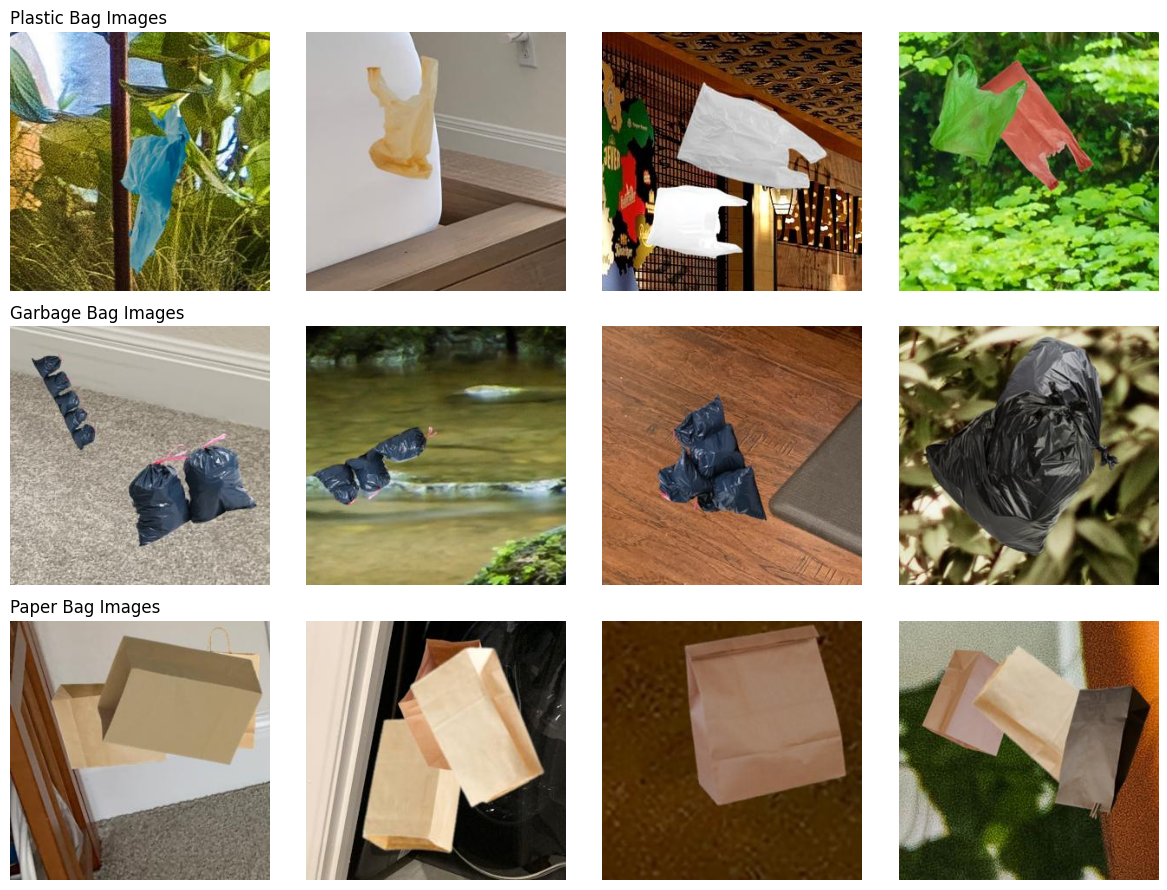

In [21]:
classes = df["label"].unique()
n_samples = 4

fig, axes = plt.subplots(len(classes), n_samples, figsize=(n_samples*3, len(classes)*3))

for row, cls in enumerate(classes):
  sample_paths = df[df["label"] == cls]["filepath"].sample(n_samples, random_state=42).values
  for col, path in enumerate(sample_paths):
      img = cv2.imread(path)
      img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
      axes[row, col].imshow(img)
      axes[row, col].axis("off")
      if col == 0:
          axes[row, col].set_ylabel(cls, fontsize=12)
  axes[row,0].set_title(cls, fontsize=12, loc="left")

plt.tight_layout()
plt.show()

The above images show accurate classification of bags.

## **OpenCV Preprocessing**

In [5]:
def preprocess_image(image_path, target_size=(224, 224)):
  img = cv2.imread(image_path)

  if img is None:
    raise ValueError(f"Could not read image at {image_path}")

  img = cv2.resize(img, target_size) # resize
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # convert BGR -> RGB
  img = img.astype(np.float32)/255.0 #Normalize to [0,1]

  return img

sample_path = df["filepath"].iloc[0]
processed = preprocess_image(sample_path)
print("Shape:", processed.shape, "Min:", processed.min(), "Max", processed.max())

Shape: (224, 224, 3) Min: 0.0 Max 0.99607843


### **What was Done**

1. Bag Classes dataset was extracted from a zip file on Google Drive that contains three folders; plastic, paper and garbage, with 5,000 images each.
2. A *preprocess_image()* function was built to read an image with OpenCV, resize it to 224x224, convert it from BGR to RGB, and normalize pixwl valuse to [0,1] range.

The sample image dimensions above confirm that the *preprocess_image()* function worked correctly. 224 indicate the weight and height in pixels, 3 refers to the number of color channels; Red, Green, Blue. The smallest and largest pixel values found anywhere in the image array were 0 and 0.99 respectively.

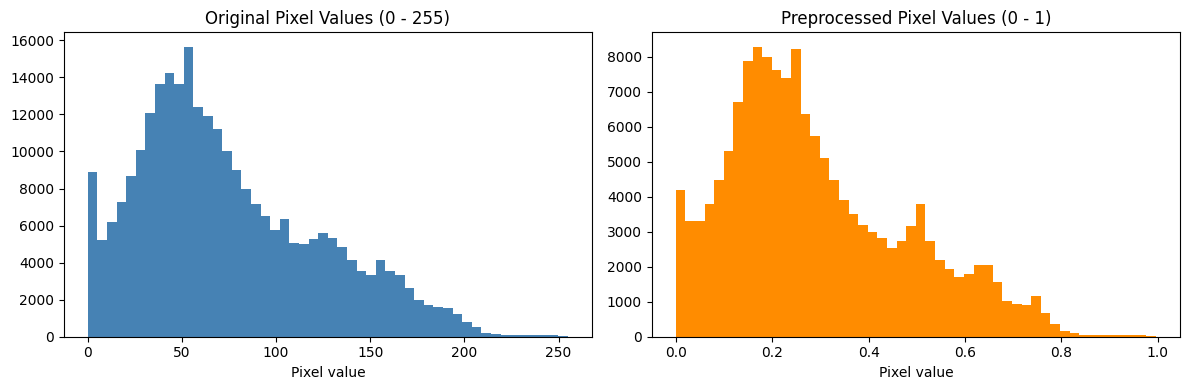

In [24]:
img_original = cv2.imread(sample_path)
img_original_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
img_preprocessed = preprocess_image(sample_path)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))


axes[0].hist(img_original_rgb.ravel(), bins=50, color="steelblue")
axes[0].set_title("Original Pixel Values (0 - 255)")
axes[0].set_xlabel("Pixel value")

axes[1].hist(img_preprocessed.ravel(), bins=50, color="darkorange")
axes[1].set_title("Preprocessed Pixel Values (0 - 1)")
axes[1].set_xlabel("Pixel value")

plt.tight_layout()
plt.show()

### **Pixel Intensity Distribution**

To make the effect of normaliztion concrete, we compare the pixel value distributions insted of the images themselves.

**Original Image** shows the raw pixel intensity distribution as read directly from the file, spread across standard 8-bit integer range. The **preprocessed image**  shows the same distribution shape compressed into [0,1] float range.

The two histograms show the **same relative distribution shape**, just rescaled, conforming that normalization perserves relationships between pixel values while changing only the numeric scale they are represented on. This is exactly the goal, scaling the input range while keeping the imagee content as it is to help the model's stability and performance.

## **Augmentation Pipeline & Image Vizualization**

In [ ]:
datagen = ImageDataGenerator(
   rotation_range = 20,
   width_shift_range = 0.1,
   height_shift_range = 0.1,
   horizontal_flip = True,
   zoom_range = 0.15,
   brightness_range = [0.8, 1.2]
)

img = cv2.imread(sample_path)
img = cv2.resize(img, (224,224)) # resize
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # convert BGR -> RGB
img_batch = np.expand_dims(img, axis=0) #ImageDataGenerator

fig, axes = plt.subplots(1,5, figsize=(15,3))
aug_iter = datagen.flow(img_batch, batch_size=1)

for i, ax in enumerate(axes):
  augmented_image = next(aug_iter)[0].astype(np.uint8)
  ax.imshow(augmented_image)
  ax.set_title(f"Augmented {i+1}")
  ax.axis("off")

plt.tight_layout()
plt.show()

## **The Chosen *preprocess_input* for the Pre-trained Model**

In [ ]:
img_for_model = cv2.imread(sample_path)
img_for_model = cv2.resize(img_for_model, (224,224))
img_for_model = cv2.cvtColor(img_for_model, cv2.COLOR_BGR2RGB)
img_for_model = preprocess_input(img_for_model.astype(np.float32))

print("Preprocesed range:", img_for_model.min(), img_for_model.max())

### **Observations**

**MobileNetV2**'s process_input scaled pixel values to a range of [-1, 0.99], confirming it uses a different normalization scheme *[-1,1]*.

Augmentation pipeline successfully genrated 5 visually distinct variations of a single sample image, confirming the model is ready to apply during model training to iprove generalization.

MobilNetV2 was selected as the pre-trained base model for this task due to its **lightweight architecture**, **strong performance** on object classification and for being suitable for a moderarely sized dataset. It was the perfict fit for our limited GPU resources.